# Customer Segmentation & Insights for E-commerce Growth

In [1]:
# Load All Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv(r"C:\Users\hp\Downloads\My Project\Customer Segmentation\Online Retail.csv")

In [3]:
# Display the first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Shape of the Dataset
df.shape

(541909, 8)

## Data Cleaning:

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [10]:
# Remove rows with negative or zero Quantity
df = df[df['Quantity'] > 0]

In [11]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,12/16/2010 14:36,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,12/21/2010 13:45,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,1/13/2011 15:10,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2/10/2011 13:08,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,3/23/2011 10:25,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,3/30/2011 12:45,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,4/4/2011 14:42,0.0,14410.0,United Kingdom


In [12]:
# Remove rows with negative or zero UnitPrice
df = df[df['UnitPrice'] > 0]

In [13]:
# Create a 'TotalPrice' column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [14]:
# Remove duplicates
df = df.drop_duplicates()  

In [15]:
# Remove canceled orders if any
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]  

In [16]:
df = df.reset_index(drop=True)

In [17]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  

In [18]:
df.shape

(392692, 9)

## EDA:

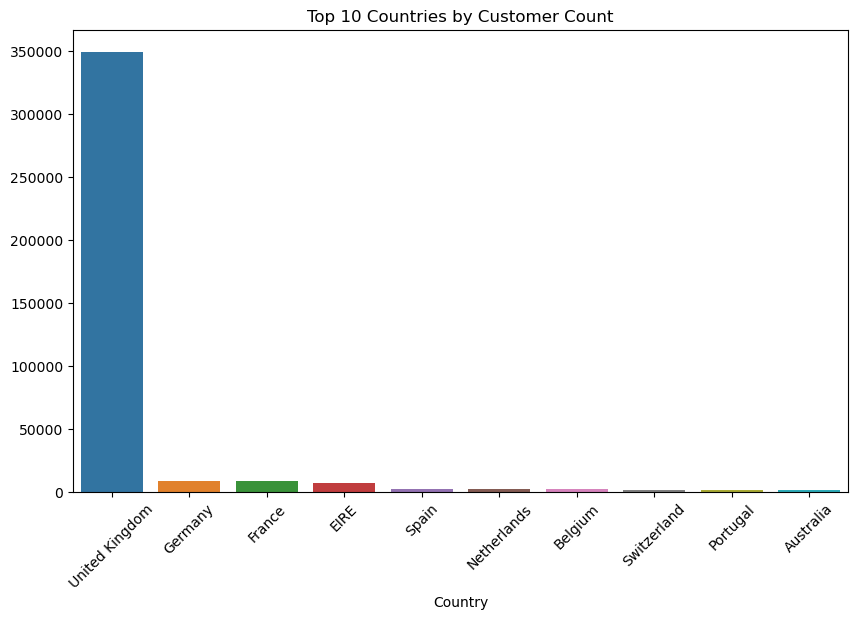

In [19]:
# Top 10 countries by customer count
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Customer Count")
plt.xticks(rotation=45)
plt.show()

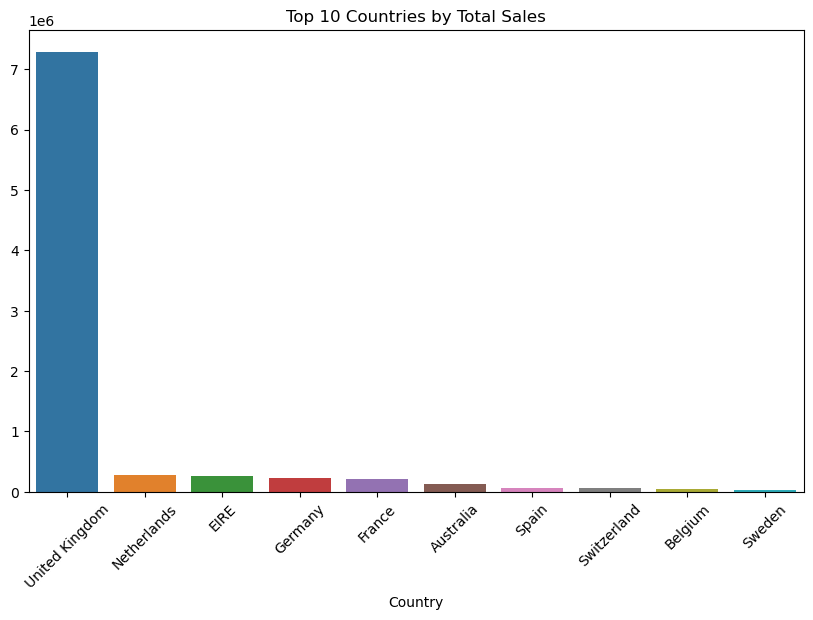

In [20]:
# Total sales per country
sales_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=sales_country.index, y=sales_country.values)
plt.title("Top 10 Countries by Total Sales")
plt.xticks(rotation=45)
plt.show()

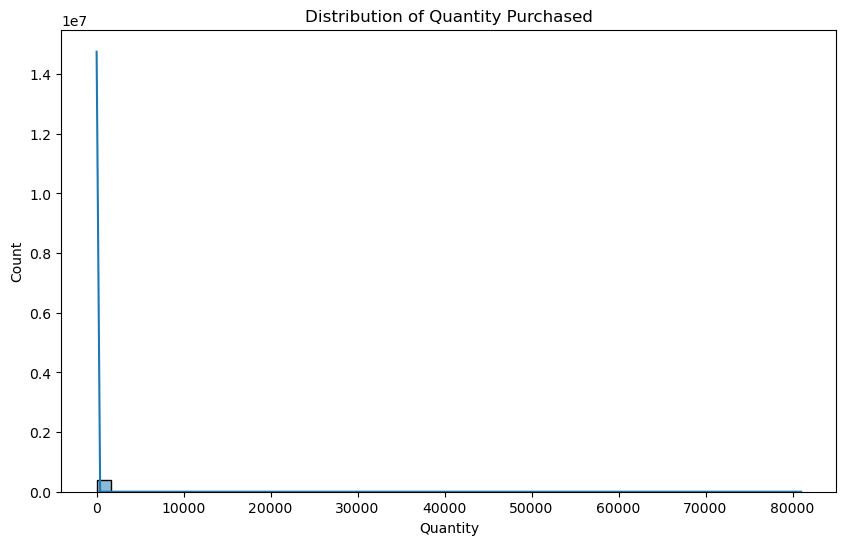

In [21]:
# Quantity distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title("Distribution of Quantity Purchased")
plt.show()

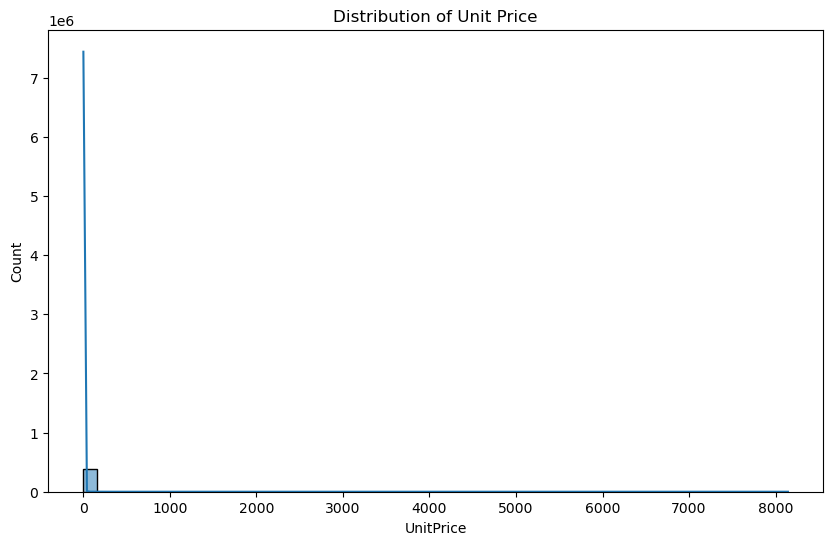

In [22]:
# Unit price distribution
plt.figure(figsize=(10,6))
sns.histplot(df['UnitPrice'], bins=50, kde=True)
plt.title("Distribution of Unit Price")
plt.show()

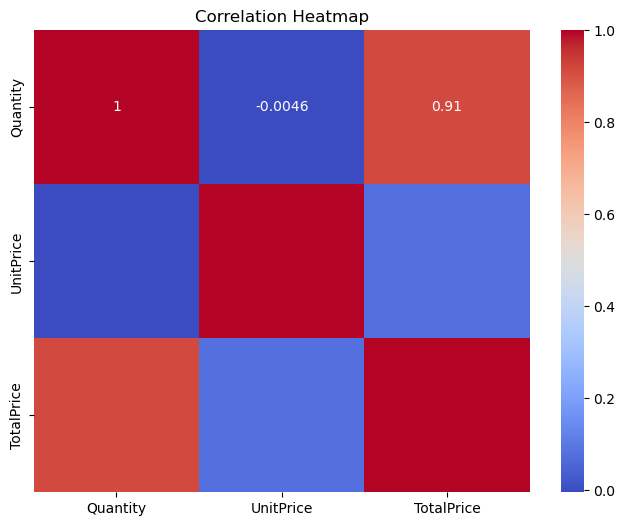

In [23]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Quantity','UnitPrice','TotalPrice']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering:

In [24]:
# Step 4: Feature Engineering (RFM + AvgBasketSize)
df['Recency'] = (df['InvoiceDate'].max() - df['InvoiceDate']).dt.days

In [25]:
rfm_df = df.groupby('CustomerID').agg(
    Recency=('Recency','min'),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('TotalPrice','sum')
).reset_index()

## Notes:
### Recency: How recently a customer made a purchase. ((Date of Last Transaction - Today).days)
### Frequency: How often a customer makes purchases in a period. (Number of transactions or orders in a given period)
### Monetary: How much money a customer has spent. (Sum of all purchase amounts)

In [26]:
rfm_df['AvgBasketSize'] = df.groupby('CustomerID')['Quantity'].mean().values

In [27]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize
0,12346.0,325,1,77183.60,74215.000000
1,12347.0,1,7,4310.00,13.505495
2,12348.0,74,4,1797.24,75.516129
3,12349.0,18,1,1757.55,8.643836
4,12350.0,309,1,334.40,11.588235


In [28]:
# Step 5: Customer Segmentation using K-Means with Min-Max Normalization
scaler = MinMaxScaler()
rfm_normalized = scaler.fit_transform(rfm_df[['Recency','Frequency','Monetary','AvgBasketSize']])

In [29]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm_df['Segment'] = kmeans.fit_predict(rfm_normalized)

In [30]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,AvgBasketSize,Segment
0,12346.0,325,1,77183.60,74215.000000,3
1,12347.0,1,7,4310.00,13.505495,0
2,12348.0,74,4,1797.24,75.516129,2
3,12349.0,18,1,1757.55,8.643836,0
4,12350.0,309,1,334.40,11.588235,3


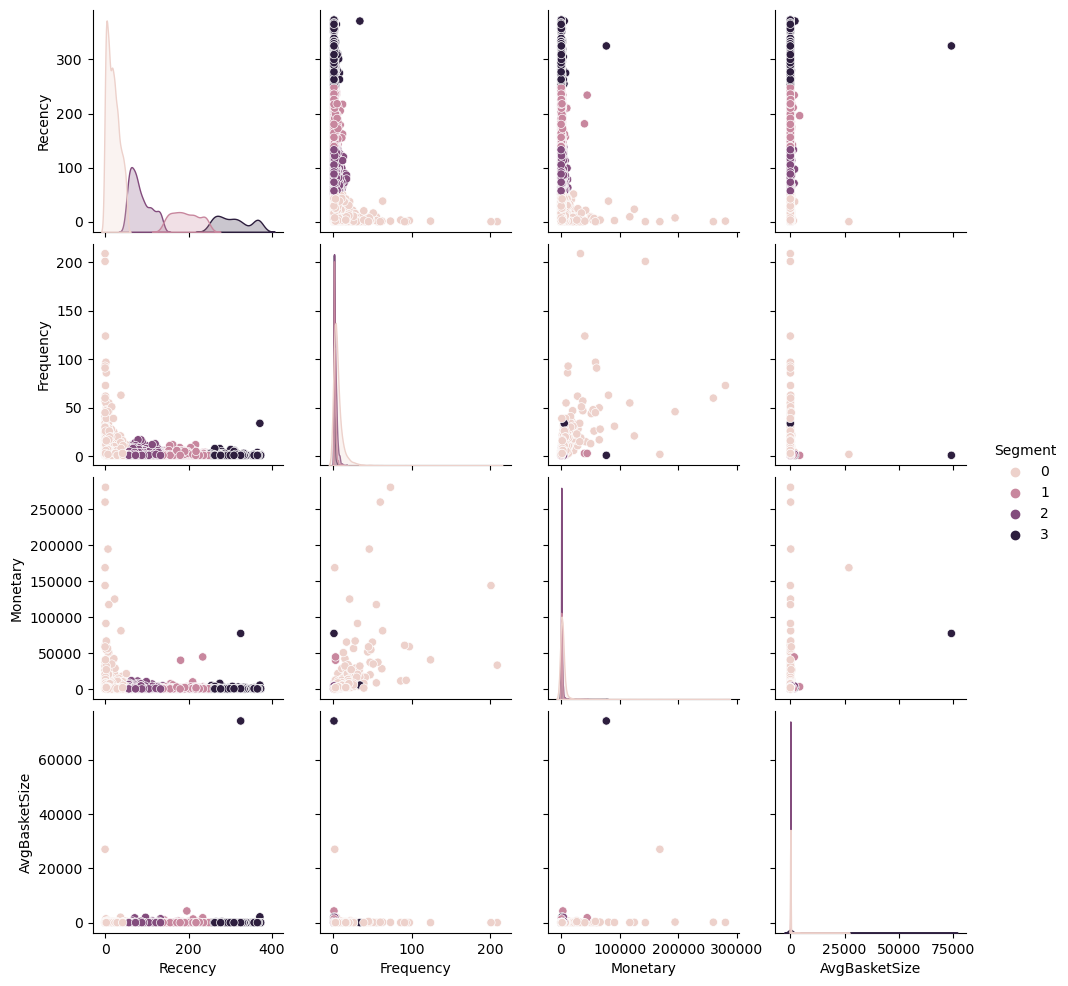

In [31]:
# Visualize clusters
sns.pairplot(rfm_df, hue='Segment', vars=['Recency','Frequency','Monetary','AvgBasketSize'])
plt.show()

## SQL Part:

In [32]:
# SQLite Integration
conn = sqlite3.connect('ecommerce.db')

In [33]:
# Save transactions and RFM tables
df.to_sql('transactions', conn, if_exists='replace', index=False)


392692

In [34]:
rfm_df.to_sql('customer_segments', conn, if_exists='replace', index=False)

4338

In [35]:
# Top 10 customers by Monetary
query1 = """
SELECT CustomerID, SUM(TotalPrice) as TotalSpent
FROM transactions
GROUP BY CustomerID
ORDER BY TotalSpent DESC
LIMIT 10
"""
top_customers = pd.read_sql(query1, conn)
print(top_customers)

   CustomerID  TotalSpent
0     14646.0   280206.02
1     18102.0   259657.30
2     17450.0   194390.79
3     16446.0   168472.50
4     14911.0   143711.17
5     12415.0   124914.53
6     14156.0   117210.08
7     17511.0    91062.38
8     16029.0    80850.84
9     12346.0    77183.60


In [36]:
# Top 10 customers by Frequency (number of orders)
query2 = """
SELECT CustomerID, COUNT(DISTINCT InvoiceNo) as NumOrders
FROM transactions
GROUP BY CustomerID
ORDER BY NumOrders DESC
LIMIT 10
"""
top_frequent_customers = pd.read_sql(query2, conn)
print(top_frequent_customers)

   CustomerID  NumOrders
0     12748.0        209
1     14911.0        201
2     17841.0        124
3     13089.0         97
4     14606.0         93
5     15311.0         91
6     12971.0         86
7     14646.0         73
8     16029.0         63
9     13408.0         62


In [37]:
# Top 10 customers by Average Order Value
query3 = """
SELECT CustomerID, AVG(TotalPrice) as AvgOrderValue
FROM transactions
GROUP BY CustomerID
ORDER BY AvgOrderValue DESC
LIMIT 10
"""
avg_order_value = pd.read_sql(query3, conn)
print(avg_order_value)

   CustomerID  AvgOrderValue
0     12346.0   77183.600000
1     16446.0   56157.500000
2     15098.0   13305.500000
3     15749.0    4453.430000
4     15195.0    3861.000000
5     13135.0    3096.000000
6     17846.0    2033.100000
7     18087.0    2027.860000
8     16532.0    1687.200000
9     16000.0    1377.077778


In [38]:
# Total sales per month
query4 = """
SELECT strftime('%Y-%m', InvoiceDate) as Month, SUM(TotalPrice) as MonthlySales
FROM transactions
GROUP BY Month
ORDER BY Month
"""
monthly_sales = pd.read_sql(query4, conn)
print(monthly_sales)

      Month  MonthlySales
0   2010-12    570422.730
1   2011-01    568101.310
2   2011-02    446084.920
3   2011-03    594081.760
4   2011-04    468374.331
5   2011-05    677355.150
6   2011-06    660046.050
7   2011-07    598962.901
8   2011-08    644051.040
9   2011-09    950690.202
10  2011-10   1035642.450
11  2011-11   1156205.610
12  2011-12    517190.440


In [39]:
# Top 10 products by quantity sold
query5 = """
SELECT Description, SUM(Quantity) as TotalQuantity
FROM transactions
GROUP BY Description
ORDER BY TotalQuantity DESC
LIMIT 10
"""
top_products = pd.read_sql(query5, conn)
print(top_products)

                          Description  TotalQuantity
0         PAPER CRAFT , LITTLE BIRDIE          80995
1      MEDIUM CERAMIC TOP STORAGE JAR          77916
2   WORLD WAR 2 GLIDERS ASSTD DESIGNS          54319
3             JUMBO BAG RED RETROSPOT          46078
4  WHITE HANGING HEART T-LIGHT HOLDER          36706
5       ASSORTED COLOUR BIRD ORNAMENT          35263
6     PACK OF 72 RETROSPOT CAKE CASES          33670
7                      POPCORN HOLDER          30919
8                  RABBIT NIGHT LIGHT          27153
9             MINI PAINT SET VINTAGE           26076


In [40]:
# Number of transactions per country
query6 = """
SELECT Country, COUNT(DISTINCT InvoiceNo) as NumTransactions
FROM transactions
GROUP BY Country
ORDER BY NumTransactions DESC
LIMIT 10
"""
transactions_country = pd.read_sql(query6, conn)
print(transactions_country)

          Country  NumTransactions
0  United Kingdom            16646
1         Germany              457
2          France              389
3            EIRE              260
4         Belgium               98
5     Netherlands               94
6           Spain               90
7        Portugal               57
8       Australia               57
9     Switzerland               51


In [41]:
# Total Sales per Country
query7 = """
SELECT Country, SUM(TotalPrice) as TotalSales
FROM transactions
GROUP BY Country
ORDER BY TotalSales DESC
"""
sales_country = pd.read_sql(query7, conn)
print(sales_country)

                 Country    TotalSales
0         United Kingdom  7.285025e+06
1            Netherlands  2.854463e+05
2                   EIRE  2.652625e+05
3                Germany  2.286784e+05
4                 France  2.089343e+05
5              Australia  1.384538e+05
6                  Spain  6.155856e+04
7            Switzerland  5.644395e+04
8                Belgium  4.119634e+04
9                 Sweden  3.836783e+04
10                 Japan  3.741637e+04
11                Norway  3.616544e+04
12              Portugal  3.337584e+04
13               Finland  2.254608e+04
14             Singapore  2.127929e+04
15       Channel Islands  2.044054e+04
16               Denmark  1.895534e+04
17                 Italy  1.748324e+04
18                Cyprus  1.350285e+04
19               Austria  1.019868e+04
20                Poland  7.334650e+03
21                Israel  7.215840e+03
22                Greece  4.760520e+03
23               Iceland  4.310000e+03
24                Canada 

In [42]:
# Top 5 Countries by Number of Customers
query8 = """
SELECT Country, COUNT(DISTINCT CustomerID) as NumCustomers
FROM transactions
GROUP BY Country
ORDER BY NumCustomers DESC
LIMIT 5
"""
top_countries_customers = pd.read_sql(query8, conn)
print(top_countries_customers)

          Country  NumCustomers
0  United Kingdom          3920
1         Germany            94
2          France            87
3           Spain            30
4         Belgium            25


In [43]:
# Average Basket Size (Average Quantity per Order) per Customer
query9 = """
SELECT CustomerID, AVG(Quantity) as AvgBasketSize
FROM transactions
GROUP BY CustomerID
ORDER BY AvgBasketSize DESC
LIMIT 10
"""
avg_basket_size = pd.read_sql(query9, conn)
print(avg_basket_size)

   CustomerID  AvgBasketSize
0     12346.0        74215.0
1     16446.0        26999.0
2     13135.0         4300.0
3     16754.0         2140.0
4     16308.0         2000.0
5     18087.0         1953.5
6     15749.0         1802.8
7     14609.0         1756.5
8     15118.0         1440.0
9     15195.0         1404.0


In [44]:
# Customer Segmentation Summary (Average RFM Metrics by Segment)
query10 = """
SELECT Segment,
       COUNT(CustomerID) as NumCustomers,
       AVG(Recency) as AvgRecency,
       AVG(Frequency) as AvgFrequency,
       AVG(Monetary) as AvgMonetary,
       AVG(AvgBasketSize) as AvgBasket
FROM customer_segments
GROUP BY Segment
ORDER BY Segment
"""
segment_summary = pd.read_sql(query10, conn)
print(segment_summary)

   Segment  NumCustomers  AvgRecency  AvgFrequency  AvgMonetary   AvgBasket
0        0          2214   19.403342      6.356369  3228.519043   30.343784
1        1           598  192.503344      1.864548   719.338095   30.804589
2        2          1029   83.518950      2.597668   999.305211   25.339952
3        3           497  307.983903      1.350101   565.027143  168.777763


In [45]:
# Close connection
conn.close()

In [46]:
rfm_df.to_csv(r"C:\Users\hp\Downloads\customer_segments.csv", index=False)


In [47]:
df.to_csv(r"C:\Users\hp\Downloads\transactions.csv", index=False)
